Analyzing 6 files...

--- PERFORMANCE SUMMARY ---
                       File  MAE_degC  Estimated_UA  Total_Energy_kJ  Total_CO2_kg
          room_data_mpc.csv    1.3536         51.36       10214775.0   2550026.987
room_data_mpc_no_co2_18.csv    1.1376         51.32       10752075.0   2769336.309
      room_data_bang_18.csv    0.6256         48.57       10853820.0   2787987.853
       room_data_mpc_18.csv    1.1225         51.12       11238075.0   2834072.347
   room_data_mpc_no_co2.csv    1.1225         51.12       11238075.0   2834073.221
         room_data_bang.csv    0.7619         48.55       11497140.0   2882809.319

Deep dive plot saved to D:\SSE\carbon aware thermostat


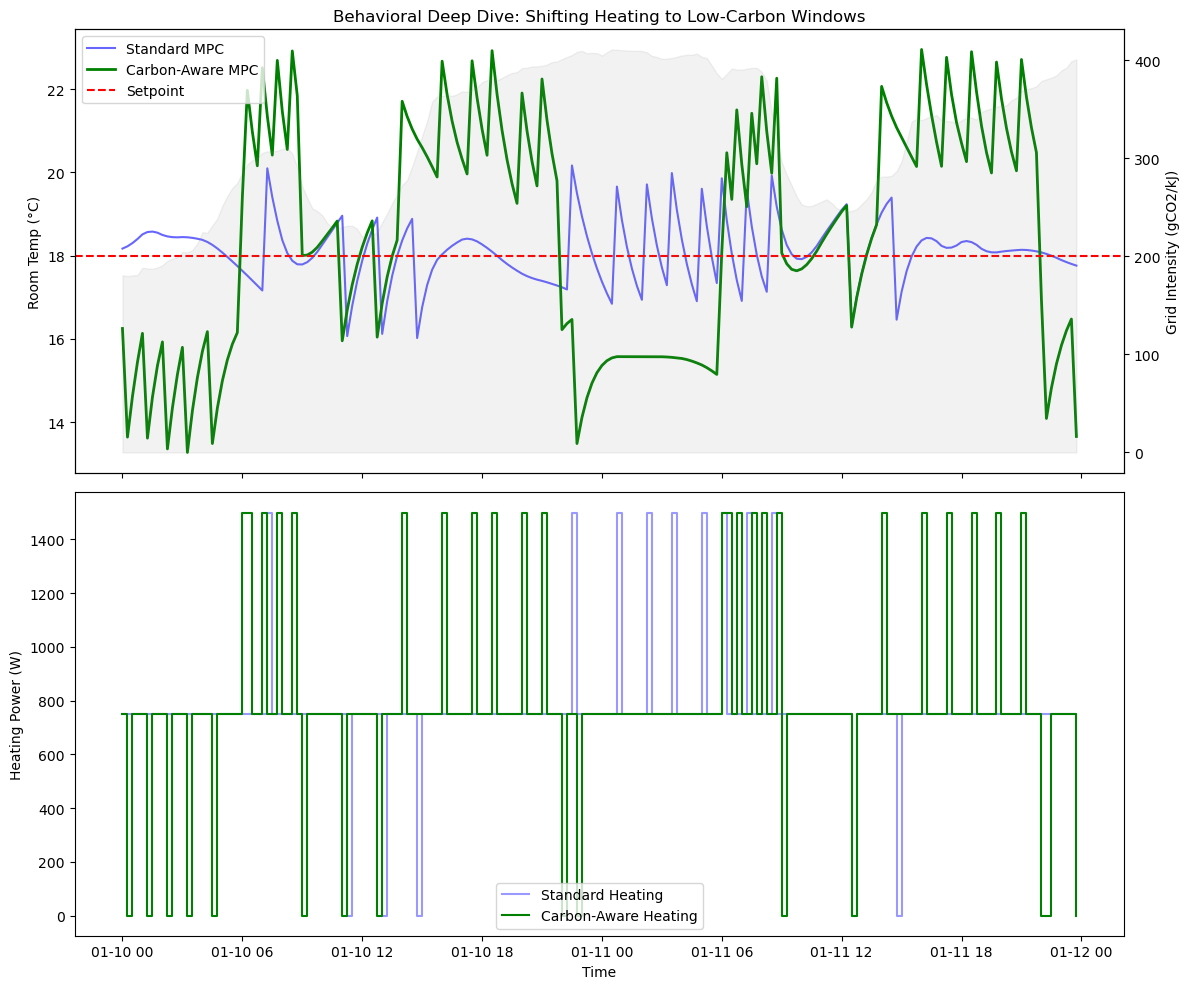

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob


DATA_DIR = r"D:\SSE\carbon aware thermostat" 


def run_thermostat_analysis(base_path):
    # Find only the relevant data files
    file_pattern = os.path.join(base_path, "room_data_*.csv")
    files = glob.glob(file_pattern)
    
    if not files:
        print(f"No CSV files found in {base_path}. Please check the path.")
        return

    results = []
    
    # We look for either of these columns as naming varies between sets
    carbon_cols = ['carbon_intensity_gco2_per_kj', 'carbon_intensity_gco2_per_kwh']

    print(f"Analyzing {len(files)} files...")

    for file_path in files:
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
        # 1. MEAN ABSOLUTE ERROR (MAE) - Comfort tracking
        target = df['preferred_room_temperature_C']
        df['error'] = np.abs(df['room_temprature'] - target)
        mae = df['error'].mean()
        
        # 2. U-VALUE (UA ESTIMATION) - Physical consistency
        # Q_conduc = UA * (T_room - T_out) * dt 
        # So UA = Q_conduc / ((T_room - T_out) * dt)
        df['delta_T'] = df['room_temprature'] - df['outside_temperature_C']
        
        # Filter for stable periods to avoid noise (Delta T > 0.5 and dt > 0)
        mask = (df['delta_T'].abs() > 0.5) & (df['dt'] > 0)
        if mask.any():
            ua_estimate = (df.loc[mask, 'Q_conduc'] / (df.loc[mask, 'delta_T'] * df.loc[mask, 'dt'])).mean()
        else:
            ua_estimate = np.nan

        # 3. ENERGY & CARBON
        # Find which carbon column exists
        carbon_col = next((c for c in carbon_cols if c in df.columns), None)
        
        if carbon_col:
            # Energy in kJ = (Wattage * dt) / 1000 
            # (Note: Heating_wattage_W * dt_seconds = Joules)
            energy_kj = (df['heating_wattage_W'] * df['dt']) / 1000
            
            if "per_kj" in carbon_col:
                # If the intensity is gCO2/kJ
                df['co2_g'] = energy_kj * df[carbon_col]
            else:
                # If the intensity is gCO2/kWh (1 kWh = 3600 kJ)
                energy_kwh = energy_kj / 3600
                df['co2_g'] = energy_kwh * df[carbon_col]
        else:
            df['co2_g'] = 0

        results.append({
            "File": file_name,
            "MAE_degC": round(mae, 4),
            "Estimated_UA": round(ua_estimate, 2) if not np.isnan(ua_estimate) else "N/A",
            "Total_Energy_kJ": round((df['heating_wattage_W'] * df['dt']).sum() / 1000, 2),
            "Total_CO2_kg": round(df['co2_g'].sum() / 1000, 3)
        })

    # Display results sorted by Carbon efficiency
    summary_df = pd.DataFrame(results).sort_values(by="Total_CO2_kg")
    print("\n--- PERFORMANCE SUMMARY ---")
    print(summary_df.to_string(index=False))
    
    summary_df.to_csv(os.path.join(base_path, "final_analysis_summary.csv"), index=False)
    
    # 4. BEHAVIORAL DEEP DIVE PLOT
    # Comparing No-CO2 vs CO2-Optimized at 18 degrees
    try:
        plot_deep_dive(base_path, "room_data_mpc_no_co2_18.csv", "room_data_mpc_18.csv")
    except Exception as e:
        print(f"\nCould not generate Deep Dive plot: {e}")

def plot_deep_dive(path, file_std, file_opt):
    df_std = pd.read_csv(os.path.join(path, file_std))
    df_opt = pd.read_csv(os.path.join(path, file_opt))
    
    for df in [df_std, df_opt]:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Selecting a 48-hour window in January
    start, end = "2025-01-10", "2025-01-12"
    mask_std = (df_std['timestamp'] >= start) & (df_std['timestamp'] < end)
    mask_opt = (df_opt['timestamp'] >= start) & (df_opt['timestamp'] < end)
    
    s = df_std[mask_std]
    o = df_opt[mask_opt]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Temp Plot
    ax1.plot(s['timestamp'], s['room_temprature'], label='Standard MPC', color='blue', alpha=0.6)
    ax1.plot(o['timestamp'], o['room_temprature'], label='Carbon-Aware MPC', color='green', linewidth=2)
    ax1.axhline(18, color='red', linestyle='--', label='Setpoint')
    ax1.set_ylabel("Room Temp (°C)")
    ax1.legend(loc='upper left')
    ax1.set_title("Behavioral Deep Dive: Shifting Heating to Low-Carbon Windows")

    # Intensity Overlay
    ax1_t = ax1.twinx()
    ax1_t.fill_between(s['timestamp'], s['carbon_intensity_gco2_per_kj'], color='gray', alpha=0.1, label='Carbon Intensity')
    ax1_t.set_ylabel("Grid Intensity (gCO2/kJ)")

    # Heating Plot
    ax2.step(s['timestamp'], s['heating_wattage_W'], label='Standard Heating', where='post', color='blue', alpha=0.4)
    ax2.step(o['timestamp'], o['heating_wattage_W'], label='Carbon-Aware Heating', where='post', color='green')
    ax2.set_ylabel("Heating Power (W)")
    ax2.set_xlabel("Time")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(path, "behavioral_deep_dive.png"))
    print(f"\nDeep dive plot saved to {path}")

# Execute
run_thermostat_analysis(DATA_DIR)


Loading data for time series...
Analysis complete. Plots saved to: D:\SSE\carbon aware thermostat


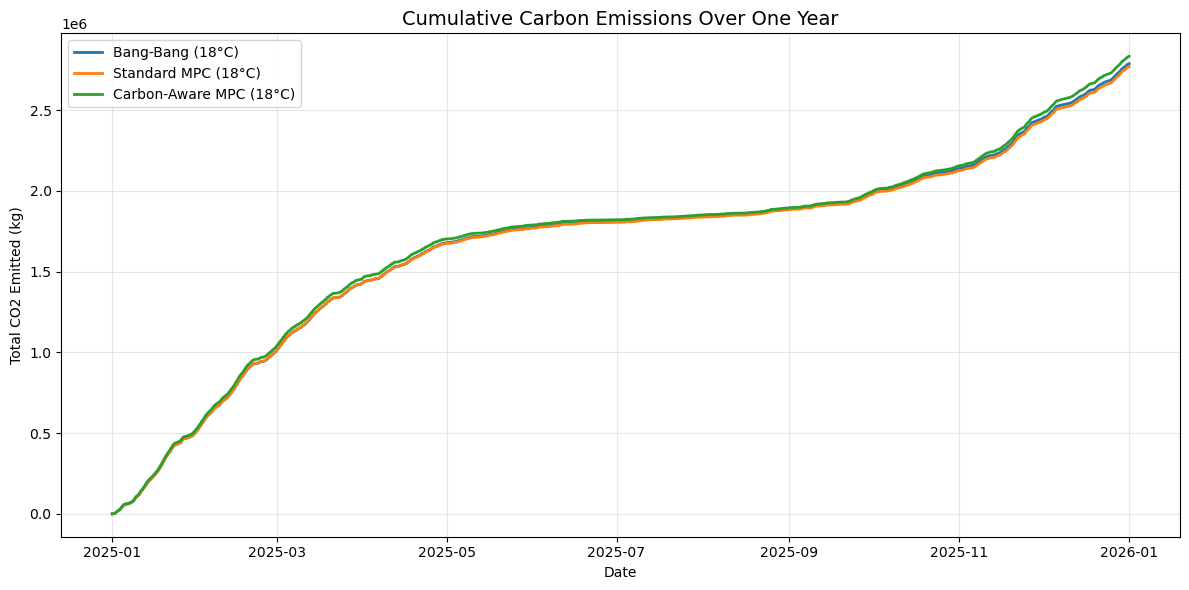

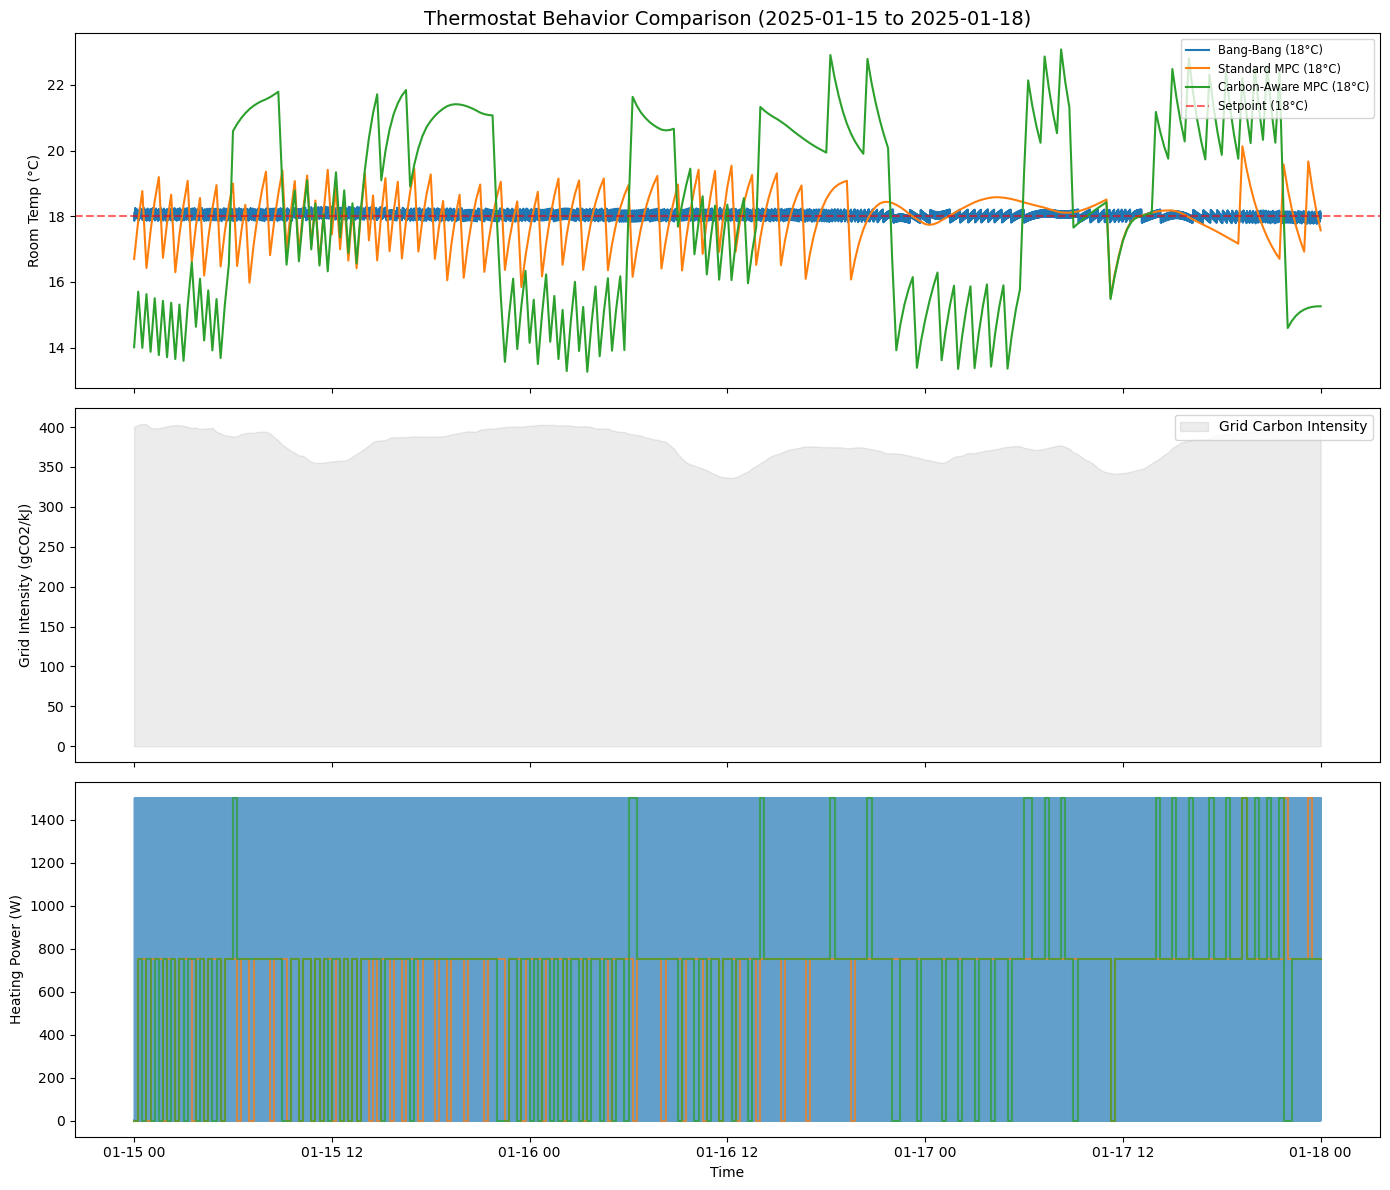

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os


DATA_DIR = r"D:\SSE\carbon aware thermostat" 


def plot_time_series_analysis(base_path):
    # Mapping the files we want to compare for the 18°C setpoint
    target_files = {
        "Bang-Bang (18°C)": "room_data_bang_18.csv",
        "Standard MPC (18°C)": "room_data_mpc_no_co2_18.csv",
        "Carbon-Aware MPC (18°C)": "room_data_mpc_18.csv"
    }
    
    data_dict = {}
    
    print("Loading data for time series...")
    for label, filename in target_files.items():
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            
            # --- ENERGY & CARBON CALCULATIONS ---
            # Energy (kJ) = (Watts * seconds) / 1000
            df['energy_kj'] = (df['heating_wattage_W'] * df['dt']) / 1000
            # CO2 (g) = Energy (kJ) * Carbon Intensity (gCO2/kJ)
            df['co2_g'] = df['energy_kj'] * df['carbon_intensity_gco2_per_kj']
            df['cum_co2_kg'] = df['co2_g'].cumsum() / 1000
            
            data_dict[label] = df
        else:
            print(f"Warning: {filename} not found.")

    if not data_dict:
        print("No files found to plot.")
        return

    # --- PLOT 1: CUMULATIVE CO2 (The Whole Year) ---
    plt.figure(figsize=(12, 6))
    for label, df in data_dict.items():
        plt.plot(df['timestamp'], df['cum_co2_kg'], label=label, linewidth=2)
    
    plt.title("Cumulative Carbon Emissions Over One Year", fontsize=14)
    plt.ylabel("Total CO2 Emitted (kg)")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, "cumulative_co2_full_year.png"))

    # --- PLOT 2: BEHAVIORAL DEEP DIVE (Winter Snapshot) ---
    # Zooming into a 3-day cold period in January
    start_zoom, end_zoom = "2025-01-15", "2025-01-18"
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    colors = {"Bang-Bang (18°C)": "#1f77b4", "Standard MPC (18°C)": "#ff7f0e", "Carbon-Aware MPC (18°C)": "#2ca02c"}

    for label, df in data_dict.items():
        mask = (df['timestamp'] >= start_zoom) & (df['timestamp'] <= end_zoom)
        sub = df[mask]
        
        # Room Temperature Plot
        ax1.plot(sub['timestamp'], sub['room_temprature'], label=label, color=colors[label], linewidth=1.5)
        # Heating Power (Wattage) Step Plot
        ax3.step(sub['timestamp'], sub['heating_wattage_W'], label=label, color=colors[label], where='post', alpha=0.7)

    # Add Setpoint reference
    ax1.axhline(18, color='red', linestyle='--', alpha=0.6, label='Setpoint (18°C)')
    ax1.set_ylabel("Room Temp (°C)")
    ax1.set_title(f"Thermostat Behavior Comparison ({start_zoom} to {end_zoom})", fontsize=14)
    ax1.legend(loc='upper right', fontsize='small')

    # Grid Carbon Intensity Plot (Shared background)
    ref_df = list(data_dict.values())[0]
    ref_mask = (ref_df['timestamp'] >= start_zoom) & (ref_df['timestamp'] <= end_zoom)
    ax2.fill_between(ref_df.loc[ref_mask, 'timestamp'], ref_df.loc[ref_mask, 'carbon_intensity_gco2_per_kj'], 
                     color='gray', alpha=0.15, label='Grid Carbon Intensity')
    ax2.set_ylabel("Grid Intensity (gCO2/kJ)")
    ax2.legend(loc='upper right')

    ax3.set_ylabel("Heating Power (W)")
    ax3.set_xlabel("Time")

    plt.tight_layout()
    plt.savefig(os.path.join(base_path, "behavioral_timeseries_zoom.png"))
    print(f"Analysis complete. Plots saved to: {base_path}")

# Run the analysis
plot_time_series_analysis(DATA_DIR)

In [5]:
import pandas as pd
import numpy as np
import os



DATA_DIR = r"D:\SSE\carbon aware thermostat" 


def calculate_carbon_correlation(base_path):
    target_files = {
        "Bang-Bang (18°C)": "room_data_bang_18.csv",
        "Standard MPC (18°C)": "room_data_mpc_no_co2_18.csv",
        "Carbon-Aware MPC (18°C)": "room_data_mpc_18.csv"
    }
    
    correlation_results = []

    print("Calculating Load Shifting Metrics...")
    
    for label, filename in target_files.items():
        file_path = os.path.join(base_path, filename)
        
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            
            # We calculate the correlation between Power and Intensity
            # We use a rolling mean (1-hour window) to capture the trend 
            # rather than instantaneous switching noise.
            
            # Determine window size based on 'dt' (assuming 900s for MPC, 60s for Bang)
            avg_dt = df['dt'].mean()
            window_size = int(3600 / avg_dt) # 1 hour window
            
            rolled_wattage = df['heating_wattage_W'].rolling(window=window_size).mean()
            rolled_intensity = df['carbon_intensity_gco2_per_kj'].rolling(window=window_size).mean()
            
            # Pearson Correlation
            corr = rolled_wattage.corr(rolled_intensity)
            
            # Calculate % of heating done during 'Clean' vs 'Dirty' periods
            median_intensity = df['carbon_intensity_gco2_per_kj'].median()
            low_carbon_energy = df[df['carbon_intensity_gco2_per_kj'] <= median_intensity]['heating_wattage_W'].sum()
            total_energy = df['heating_wattage_W'].sum()
            low_carbon_ratio = (low_carbon_energy / total_energy) * 100

            correlation_results.append({
                "Controller": label,
                "Carbon_Correlation (r)": round(corr, 4),
                "Low_Carbon_Heating_%": f"{round(low_carbon_ratio, 1)}%"
            })
            
    # Display Results
    corr_df = pd.DataFrame(correlation_results)
    print("\n--- LOAD SHIFTING EFFICIENCY ---")
    print(corr_df.to_string(index=False))
    
    # Save to CSV
    corr_df.to_csv(os.path.join(base_path, "carbon_correlation_analysis.csv"), index=False)

calculate_carbon_correlation(DATA_DIR)

Calculating Load Shifting Metrics...

--- LOAD SHIFTING EFFICIENCY ---
             Controller  Carbon_Correlation (r) Low_Carbon_Heating_%
       Bang-Bang (18°C)                  0.4530                34.7%
    Standard MPC (18°C)                  0.4412                34.4%
Carbon-Aware MPC (18°C)                  0.3771                35.9%


Loading and processing data for final analysis...


C:\Users\prana\AppData\Local\Temp\ipykernel_34684\1158760199.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Controller', y='room_temprature', data=full_df, palette="muted", inner="quartile")


Saved: temperature_distribution_violin.png
Saved: monthly_carbon_comparison.png


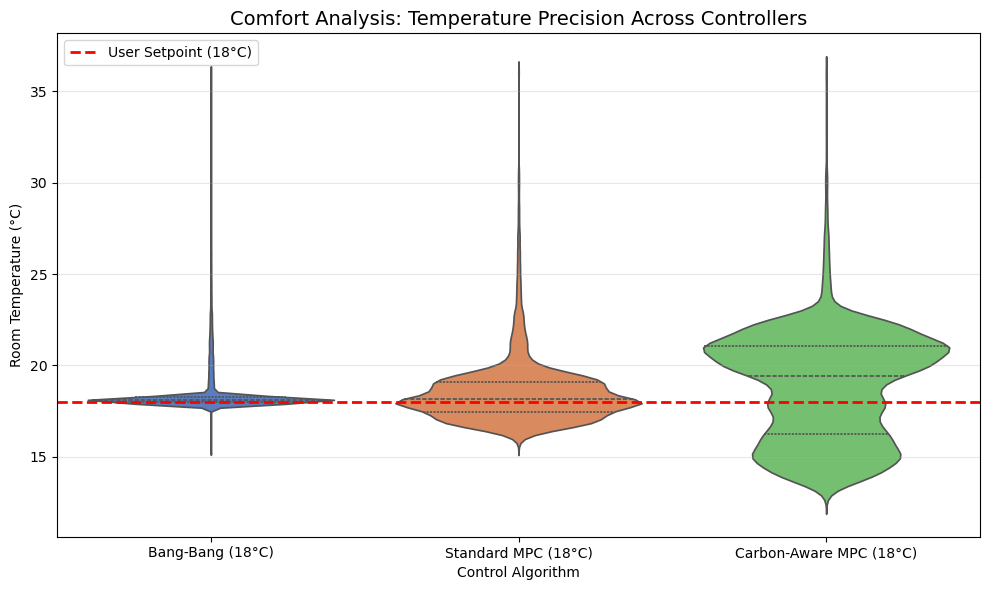

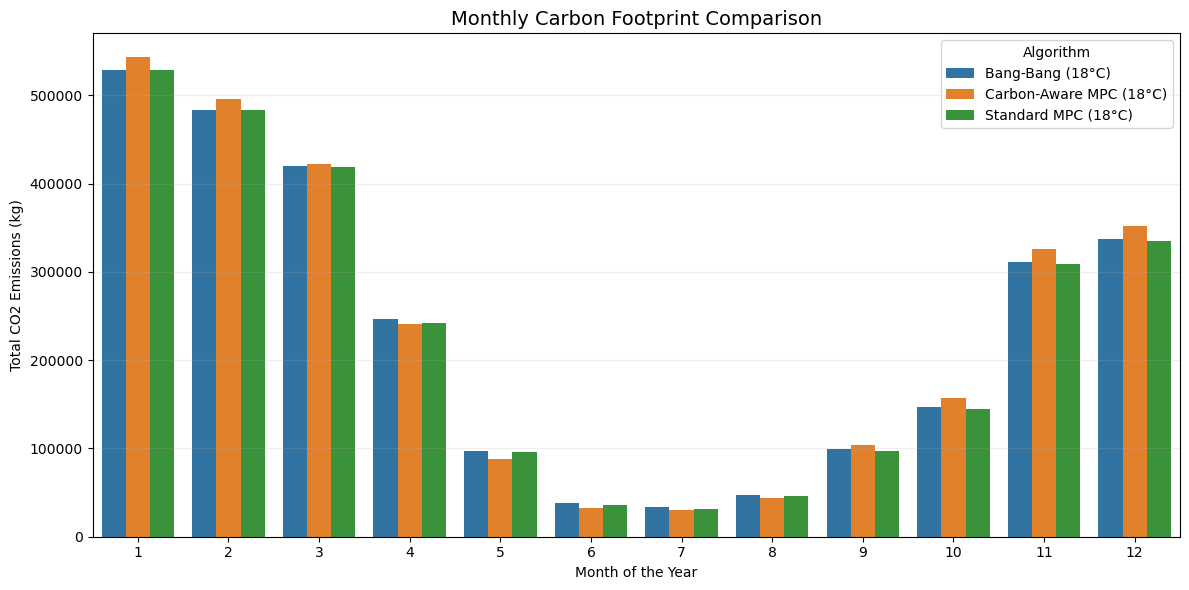

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = r"D:\SSE\carbon aware thermostat" 

def plot_distribution_and_monthly(base_path):
    # Standardizing on the 18°C setpoint files
    target_files = {
        "Bang-Bang (18°C)": "room_data_bang_18.csv",
        "Standard MPC (18°C)": "room_data_mpc_no_co2_18.csv",
        "Carbon-Aware MPC (18°C)": "room_data_mpc_18.csv"
    }
    
    all_data = []

    print("Loading and processing data for final analysis...")
    
    for label, filename in target_files.items():
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df['Month'] = df['timestamp'].dt.month
            df['Controller'] = label
            
            # CO2 Calculation: (Watts * seconds) / 1000 = kJ
            # kJ * gCO2/kJ = total gCO2. Then divide by 1000 for kg.
            df['co2_kg'] = ((df['heating_wattage_W'] * df['dt']) / 1000 * df['carbon_intensity_gco2_per_kj']) / 1000
            
            all_data.append(df)

    if not all_data:
        print("No files found.")
        return

    full_df = pd.concat(all_data)

    # --- PLOT 1: TEMPERATURE DISTRIBUTION (Violin Plot) ---
    plt.figure(figsize=(10, 6))
    # A Violin plot shows the full distribution, including the peaks (overshoot) and dips (undershoot)
    sns.violinplot(x='Controller', y='room_temprature', data=full_df, palette="muted", inner="quartile")
    
    # Reference line for the 18°C target
    plt.axhline(18, color='red', linestyle='--', linewidth=2, label='User Setpoint (18°C)')
    
    plt.title("Comfort Analysis: Temperature Precision Across Controllers", fontsize=14)
    plt.ylabel("Room Temperature (°C)")
    plt.xlabel("Control Algorithm")
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, "temperature_distribution_violin.png"))
    print("Saved: temperature_distribution_violin.png")

    # --- PLOT 2: MONTHLY CARBON COMPARISON (Bar Chart) ---
    # Aggregate CO2 by Month and Controller
    monthly_agg = full_df.groupby(['Month', 'Controller'])['co2_kg'].sum().reset_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Month', y='co2_kg', hue='Controller', data=monthly_agg)
    
    plt.title("Monthly Carbon Footprint Comparison", fontsize=14)
    plt.ylabel("Total CO2 Emissions (kg)")
    plt.xlabel("Month of the Year")
    plt.grid(axis='y', alpha=0.2)
    plt.legend(title="Algorithm")
    plt.tight_layout()
    plt.savefig(os.path.join(base_path, "monthly_carbon_comparison.png"))
    print("Saved: monthly_carbon_comparison.png")

# Execute
plot_distribution_and_monthly(DATA_DIR)